# Week 5 Assignment

Tämän viikon tehtävän tarkoitus on oppia jäännösyhteyksistä (residual connections) ja kerrosnormalisoinnista (layer normalization), niiden toteuttamisesta sekä koostaa malli käyttäen näitä komponentteja (Transformer-enkooderi lohko). Ennen mallin toteuttamista, ladataan tarvittavat kirjastot ja ainestot

In [ ]:
import keras
from keras.datasets import imdb

max_features = 10000 # vocabulary size
max_len = 250 # words per sample

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# pad all samples to same length
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len, padding='post')

Ladattu IMBD:n sisältö on tallennettu binääriseen muotoon.  Tämä koodiblokki kääntää sisällön toisinpäin.

In [ ]:
word_to_index = imdb.get_word_index()
index_to_word = dict((value, key) for (key, value) in word_to_index.items())

example_review = " ".join(index_to_word.get(i-3, "?") for i in x_train[0])
print(example_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

# Positinonal embedding

Transformer-malli käsittelee kaikki sanat rinnakkain ja ei ymmärrä sanojen järjestystä. Positional embedding lisää jokaiseen sanaan paikkatietoa kuvaavan vektorin, jolloin malli kykenee erottamaan sanojen sijainnin

In [ ]:
from keras.layers import Layer, Embedding

class TokenAndPositionEmbedding(Layer):
    def __init__(self, seq_len, vocab_size, emb_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=emb_dim)
        self.pos_emb = Embedding(input_dim=seq_len, output_dim=emb_dim)

    def call(self, x_input):
        seq_len = keras.ops.shape(x_input)[-1]
        positions = keras.ops.arange(start=0, stop=seq_len, step=1)
        positions = self.pos_emb(positions)
        x_input = self.token_emb(x_input)
        return x_input + positions

In [ ]:
from keras.layers import Input, Dense, GlobalAveragePooling1D, Dropout
from keras.models import Model

embed_dim = 32 # word embeddings dimension

inputs = Input(shape=(max_len,))
x = TokenAndPositionEmbedding(max_len, max_features, embed_dim)(inputs)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_2  │ (None, 250, 32)        │       328,000 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,033 (1.25 MB)

 Trainable params: 328,033 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6671 - loss: 0.6407
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8075 - loss: 0.4883
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8525 - loss: 0.3842
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8740 - loss: 0.3296
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8890 - loss: 0.2945


In [ ]:
print(f'Test accuracy = {model.evaluate(x_test, y_test)[1]:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8738 - loss: 0.3100
Test accuracy = 0.8738


# Self-attention

Self-attention auttaa mallin ymmärtämään sanojen välisiä suhteita ja asiayhteyttä. Kun malli käsittelee tiettyä sanaa, se katsoo lauseen muita sanoja ja päättelee, mitkä niistä ovat merkityksellisiä kyseisen sanan kannalta.

In [ ]:
from keras.layers import Layer, MultiHeadAttention

num_heads = 2 # number of attention heads
key_dim = embed_dim // num_heads

inputs = Input(shape=(max_len,))
x = TokenAndPositionEmbedding(max_len, max_features, embed_dim)(inputs)
attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
x = GlobalAveragePooling1D()(attention_output)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs=inputs, outputs=outputs)

att_model = Model(inputs=inputs, outputs=outputs)
att_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

att_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 250, 32)   │    328,000 │ input_layer_3[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 250, 32)   │      4,224 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 332,257 (1.27 MB)

 Trainable params: 332,257 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
att_model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 92ms/step - accuracy: 0.7638 - loss: 0.4521
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.8960 - loss: 0.2632
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.9164 - loss: 0.2131
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.9307 - loss: 0.1812
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.9428 - loss: 0.1533


In [ ]:
print(f'Test accuracy = {att_model.evaluate(x_test, y_test)[1]:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8396 - loss: 0.4162
Test accuracy = 0.8396


In [ ]:
inps = att_model.input
embedding_output = att_model.layers[1](inps)
att_output, att_scores = att_model.layers[2](embedding_output, embedding_output, return_attention_scores=True)
score_model = Model(inputs=inps, outputs=[att_output, att_scores])

In [ ]:
sample_input = x_train[:1]  # a single training example
_, attention_scores_all = score_model.predict(sample_input)

# scores for a single attention head
head_index = 1
attention_scores = attention_scores_all[0][head_index]

# Verify the shape of attention scores
print(f"Attention scores, full shape: {attention_scores_all.shape}")
print(f"Attention scores, one head: {attention_scores.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Attention scores, full shape: (1, 2, 250, 250)
Attention scores, one head: (250, 250)


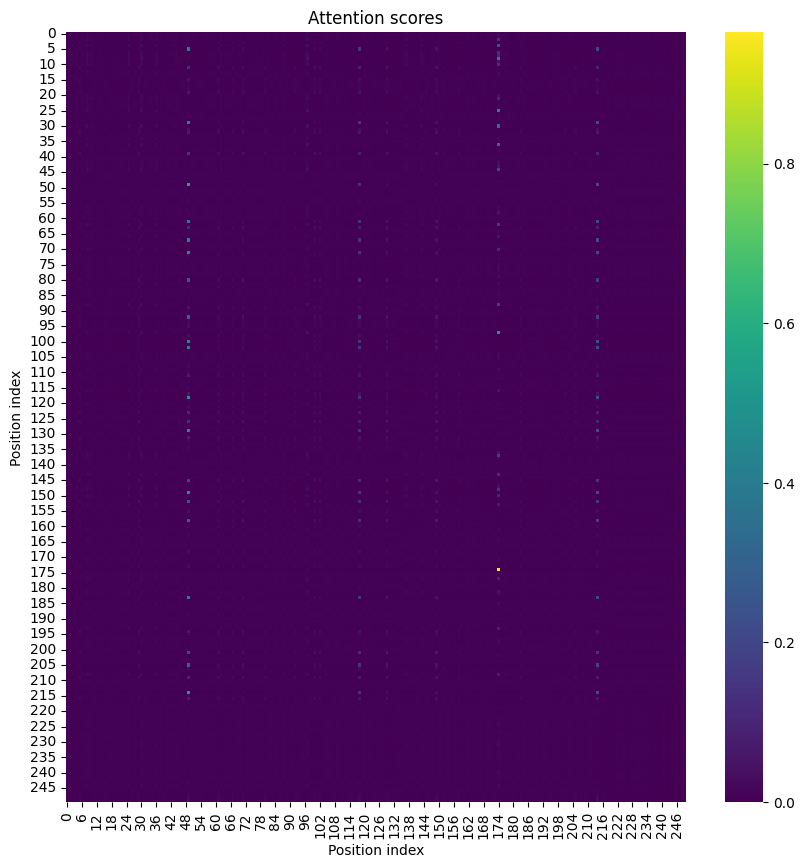

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.heatmap(attention_scores, cmap='viridis')
plt.title('Attention scores')
plt.xlabel('Position index')
plt.ylabel('Position index')
plt.show()

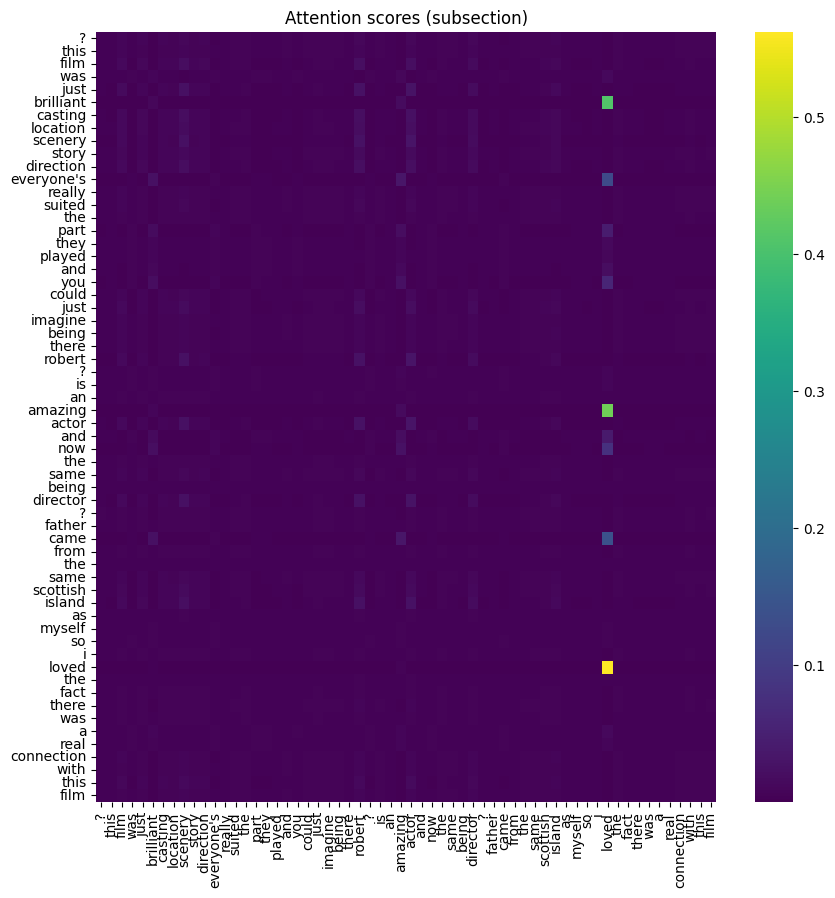

In [ ]:
sub_length = 60  # Adjust the length of the subsection as needed
sub_scores = attention_scores[:sub_length, :sub_length]

# Plot the attention scores for the subsection
plt.figure(figsize=(10, 10))
sns.heatmap(sub_scores,
            cmap='viridis',
            xticklabels=[index_to_word.get(i-3, '?') for i in sample_input[0][:sub_length]],
            yticklabels=[index_to_word.get(i-3, '?') for i in sample_input[0][:sub_length]])
plt.title('Attention scores (subsection)')
plt.show()

# Transformer Encoder Block

Transformer Encoder Block neuroverkon komponentti, joka muuntaa syötesekvenssit (Tekstit yms.) numeerisiksi esityksiksi - eli sellaiseen muotoon, että tietokone ymmärtää sanojen merkityksen ja niiiden väliset suhteet.



In [34]:
from keras.layers import Add, LayerNormalization, ReLU

x_input = TokenAndPositionEmbedding(max_len, max_features, embed_dim)(inputs)

attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x_input, x_input)

x = Add()([x_input, attention_output])
x = LayerNormalization()(x)

ffn = Dense(embed_dim * 2, activation='relu')(x)
ffn = Dense(embed_dim)(ffn)

x = Add()([x, ffn])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 250, 32)   │    328,000 │ input_layer_3[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 250, 32)   │      4,224 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 250, 32)   │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 250, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 250, 32)   │      2,080 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 250, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1)         │         33 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 336,577 (1.28 MB)

 Trainable params: 336,577 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - accuracy: 0.9734 - loss: 0.0811 - val_accuracy: 0.8516 - val_loss: 0.5381
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 140ms/step - accuracy: 0.9788 - loss: 0.0671 - val_accuracy: 0.8478 - val_loss: 0.6107
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.9825 - loss: 0.0574 - val_accuracy: 0.8376 - val_loss: 0.6378
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 139ms/step - accuracy: 0.9855 - loss: 0.0462 - val_accuracy: 0.8429 - val_loss: 0.6836
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 123s 157ms/step - accuracy: 0.9864 - loss: 0.0415 - val_accuracy: 0.8434 - val_loss: 0.7440


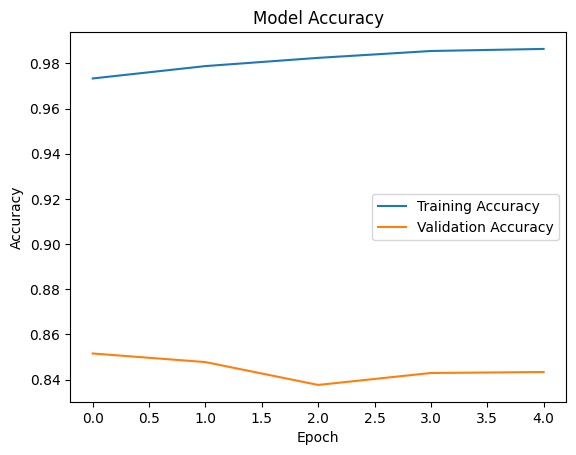

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [43]:
results = model.evaluate(x_test, y_test)
print(f"Test Loss: {results}")
print(f"Test Accuracy: {results}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8434 - loss: 0.7440
Test Loss: [0.7439852356910706, 0.8433600068092346]
Test Accuracy: [0.7439852356910706, 0.8433600068092346]


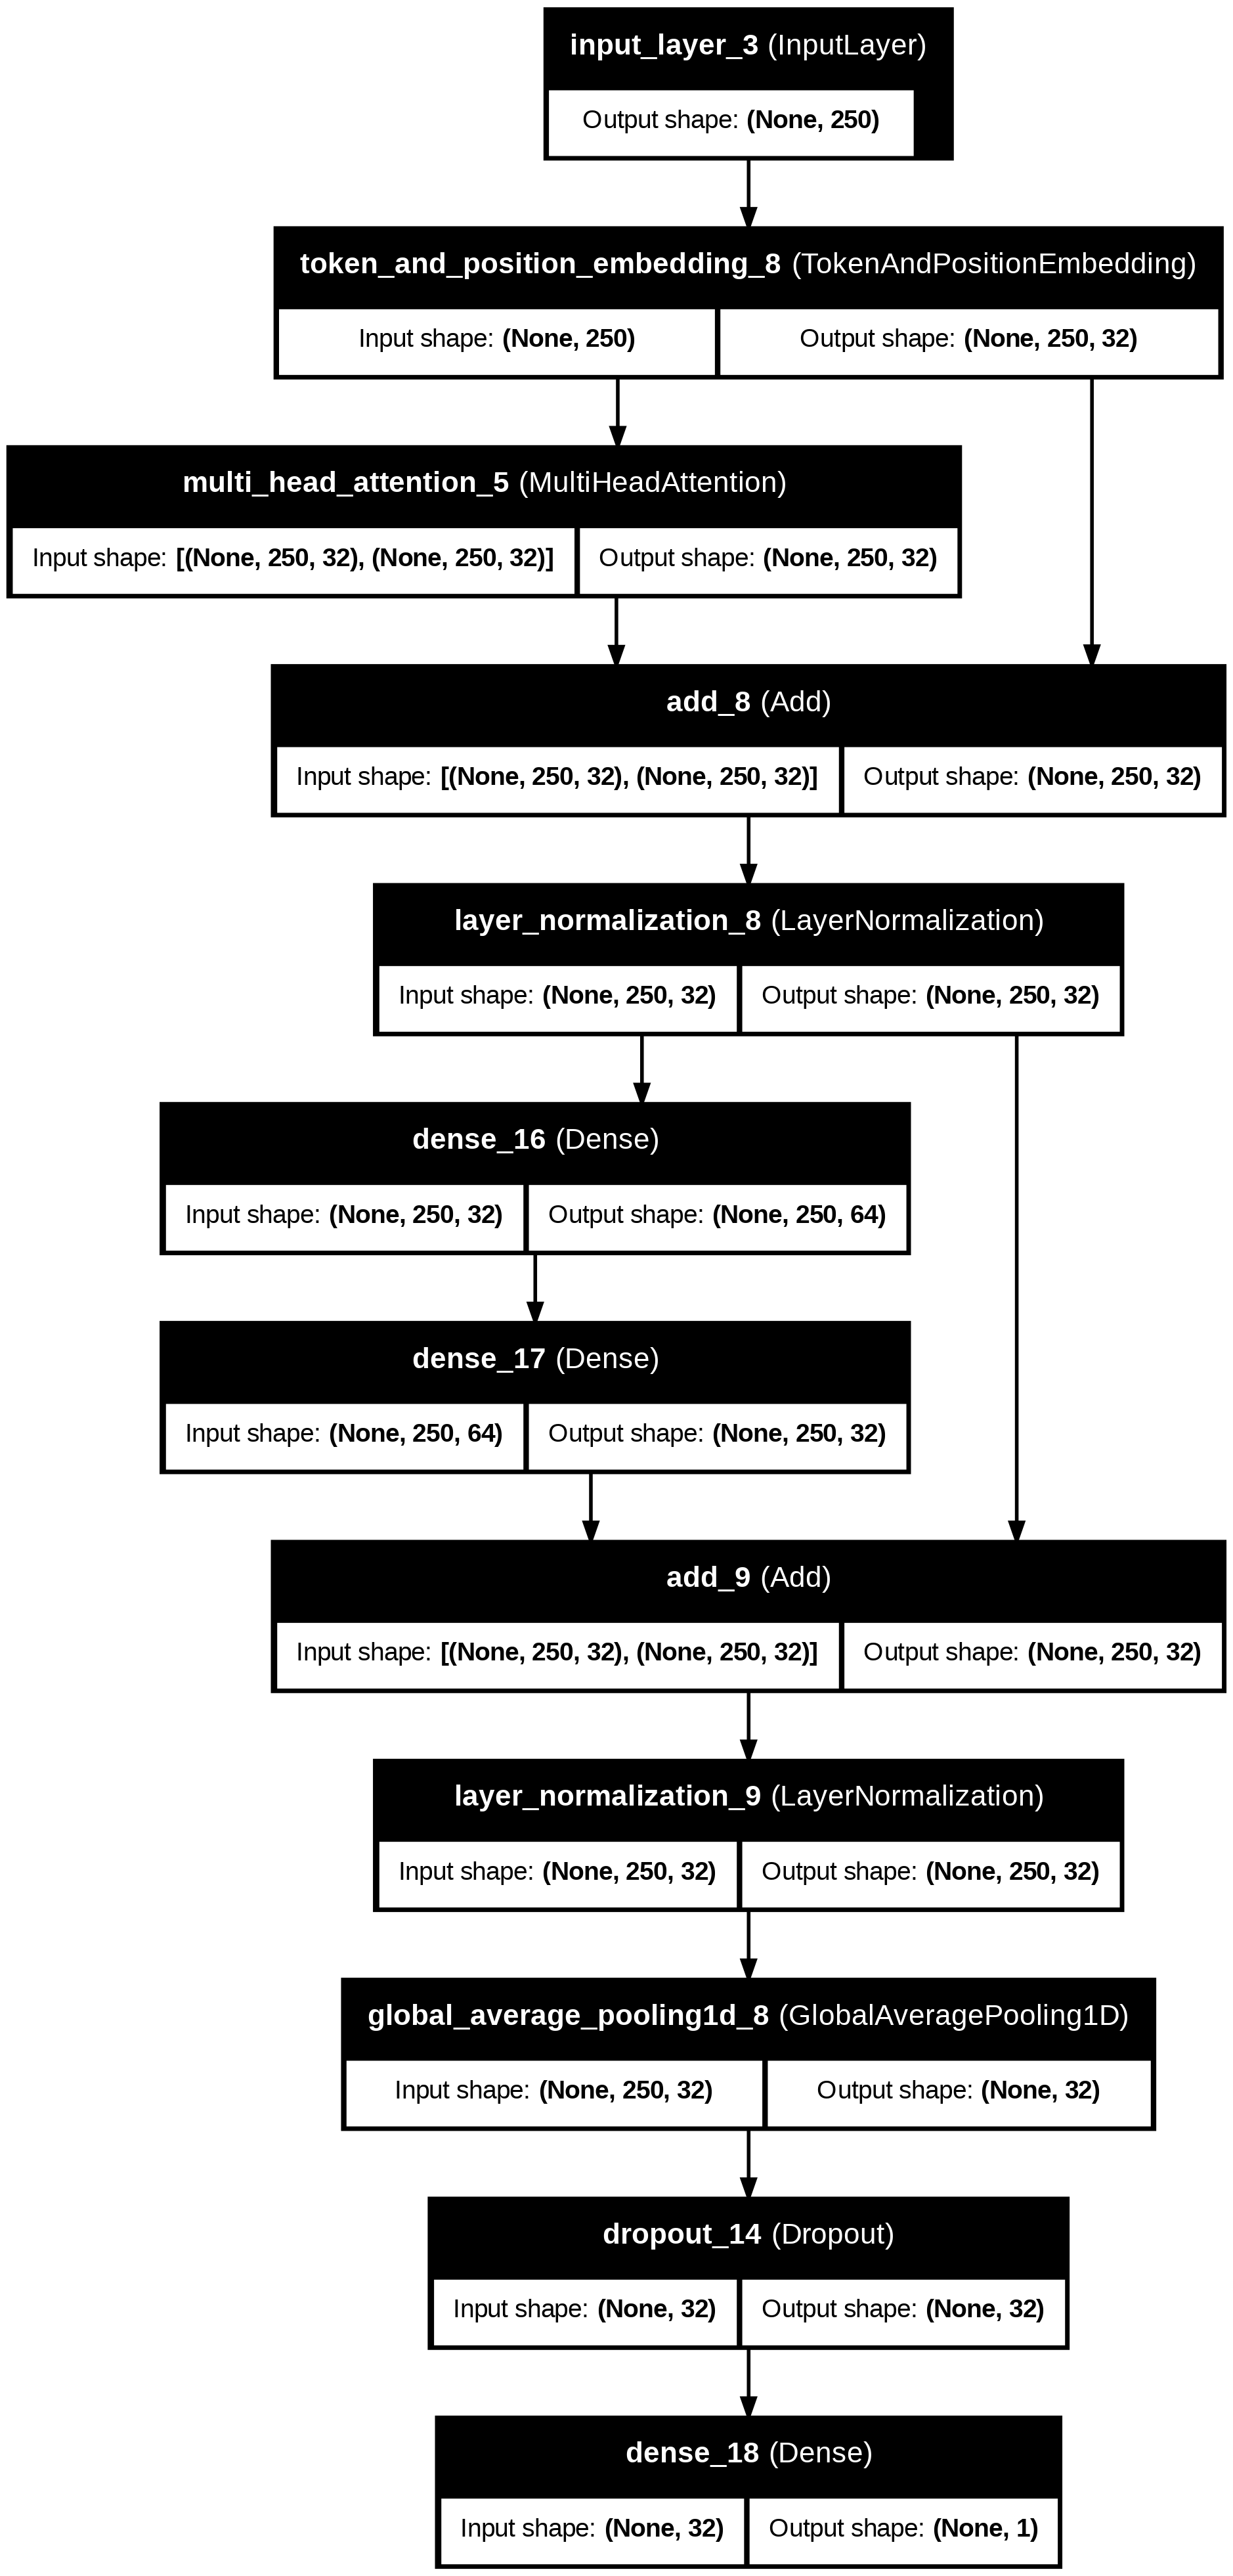

In [44]:
from keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True)